# Chapter 25 — When Your Benchmark Is Too Easy

**Companion to *Applied AI*.**

Chapter 24 ended 11/12 vs 11/12: "no difference observed" — which may only
be evidence of a ceiling. This notebook recomputes the harder-corpus run
(P1.1, 40 tasks, 280 calls) from its frozen rows and shows the nuanced
result: coverage rose while candidate reliability fell, and the difference
was not a proven advantage.

## Question

**Did the harder corpus reveal a real difference?**

## What this notebook does

It **reproduces** `p-series/p11/p11-export.json`: coverage 27 / 31 / 33
against falling candidate rates, the per-model slot split inside the
portfolio, the four discordant tasks read one by one, and the sign test at
p = 0.625 — computed here, not quoted.

```text
coverage  ≠  candidate reliability  ≠  a proven advantage
```

## Setup

Standard library only — plus `matplotlib` for one plot. No network, no API
key, no `codeai` import. Only bundle-relative paths are shown; override the
evidence root with `APPLIED_AI_EVIDENCE`.

In [1]:
import json
import os
from math import comb
from collections import defaultdict
from pathlib import Path

def find_evidence_dir(marker="p-series"):
    """Locate the preserved evidence. Override with APPLIED_AI_EVIDENCE."""
    env = os.environ.get("APPLIED_AI_EVIDENCE")
    if env and Path(env).expanduser().is_dir():
        return Path(env).expanduser()
    here = Path.cwd().resolve()
    for base in (here, *here.parents):
        for cand in (base / "evidence",
                     base / "experiments" / "applied-ai" / "evidence"):
            if (cand / marker).is_dir():
                return cand
    raise FileNotFoundError(
        "Preserved evidence not found. Set APPLIED_AI_EVIDENCE to the "
        "directory holding the Applied AI evidence bundles.")

EVIDENCE_DIR = find_evidence_dir()
EXPORT = EVIDENCE_DIR / "p-series" / "p11" / "p11-export.json"
print("bundle: p-series/p11/p11-export.json")
data = json.loads(EXPORT.read_text(encoding="utf-8"))
cands = data["candidates"]
calls = {c["call_id"]: c for c in data["calls"]}
print("corpus:", data["experiment"]["corpus_version"],
      "| candidates:", len(cands), "| calls:", len(calls))

bundle: p-series/p11/p11-export.json
corpus: semantic-repair-v1 | candidates: 280 | calls: 280


## 1. Coverage rose while candidates got worse

Read both denominators at once. Coverage asks whether *at least one*
candidate per task passed; candidate reliability is the observed pass rate
under the frozen verifier. Recomputed from the 280 rows:

In [2]:
PASS = "VERIFIER_PASS"
solved = defaultdict(set)
passes = defaultdict(int)
total = defaultdict(int)
for c in cands:
    total[c["arm"]] += 1
    if c["outcome"] == PASS:
        solved[c["arm"]].add(c["corpus_task_id"])
        passes[c["arm"]] += 1

rep = data["report"]["arms"]
print(f"{'arm':<4}{'coverage':<12}{'cand. rate':<14}tokens")
print("-" * 44)
for arm, n in (("C0", 40), ("C1", 120), ("H1", 120)):
    print(f"{arm:<4}{len(solved[arm])}/40 ({len(solved[arm])/40:.3f})  "
          f"{passes[arm]}/{n} ({passes[arm]/n:.3f})   {rep[arm]['tokens']:,}")
assert (len(solved["C0"]), len(solved["C1"]), len(solved["H1"])) == (27, 31, 33)
assert (passes["C0"], passes["C1"], passes["H1"]) == (27, 78, 64)
print()
print("The portfolio covered two more tasks while producing fourteen fewer")
print("passing candidates in the same 120 slots. Not a contradiction — the")
print("frozen rows show exactly why (next cell).")

arm coverage    cand. rate    tokens
--------------------------------------------
C0  27/40 (0.675)  27/40 (0.675)   7,521
C1  31/40 (0.775)  78/120 (0.650)   22,696
H1  33/40 (0.825)  64/120 (0.533)   29,484

The portfolio covered two more tasks while producing fourteen fewer
passing candidates in the same 120 slots. Not a contradiction — the
frozen rows show exactly why (next cell).


## 2. Why: the portfolio's slots

H1 is not "three models" in the abstract. Per task it spends one slot on the
baseline model and two on other models — and in the observed rows, two of
every three slots came from models with lower pass rates than its qwen slot.
Split H1's candidates by the model that actually produced them:

In [3]:
slot = defaultdict(lambda: defaultdict(int))
for c in cands:
    if c["arm"] == "H1":
        m = calls[c["call_id"]]["model"]
        slot[m]["tot"] += 1
        if c["outcome"] == PASS:
            slot[m]["pass"] += 1
        if c["outcome"] == "EXECUTION_ERROR":
            slot[m]["err"] += 1

for m in ("qwen2.5-coder:latest", "llama3.1:8b", "mistral:7b-instruct"):
    s = slot[m]
    print(f"{m:<22}{s['pass']}/{s['tot']} ({s['pass']/s['tot']:.3f})"
          f"{' + %d exec errors' % s['err'] if s['err'] else ''}")
assert slot["qwen2.5-coder:latest"]["pass"] == 30
assert slot["llama3.1:8b"]["pass"] == 19
assert slot["mistral:7b-instruct"]["pass"] == 15
print()
print("Aggregate candidate rate fell because most slots were weaker draws —")
print("true in total, not everywhere: H1 passed more candidates than C1 on")
print("six tasks. Coverage still rose because coverage asks only whether ANY")
print("slot passed. Without a selector, that extra coverage is potential,")
print("not delivered.")

qwen2.5-coder:latest  30/40 (0.750)
llama3.1:8b           19/40 (0.475)
mistral:7b-instruct   15/40 (0.375) + 3 exec errors

Aggregate candidate rate fell because most slots were weaker draws —
true in total, not everywhere: H1 passed more candidates than C1 on
six tasks. Coverage still rose because coverage asks only whether ANY
slot passed. Without a selector, that extra coverage is potential,
not delivered.


## 3. Four tasks that disagree, read one by one

A rescue is not automatically a model-specific rescue. The arms disagree on
exactly four tasks — each needs its own reading, because the aggregates
mislead about all four:

In [4]:
h1_only = sorted(solved["H1"] - solved["C1"])
c1_only = sorted(solved["C1"] - solved["H1"])
print("H1-only solves:", h1_only)
print("C1-only solves:", c1_only)
assert h1_only == ["v2-half-up-rounding", "v2-keyed-cache-length", "v2-strip-query"]
assert c1_only == ["v2-splitlines-cr"]

# Who passed what on the discordant tasks?
for t in h1_only + c1_only:
    who = sorted({calls[c["call_id"]]["model"].split(":")[0]
                  for c in cands if c["corpus_task_id"] == t
                  and c["outcome"] == PASS})
    print(f"  {t:<22} passed by: {who}")

print()
print("v2-strip-query      : all 4 baseline draws failed; mistral passed by a")
print("                      different route (urllib.parse). Clean rescue shape.")
print("v2-half-up-rounding : the pass came from H1's BASELINE-model slot.")
print("                      Sampling variation, not diversity.")
print("v2-keyed-cache-length: all 3 H1 draws passed, all 4 baseline failed.")
print("                      Fits two stories. Kept ambiguous.")
print("v2-splitlines-cr    : C1 solved it; all 3 H1 draws failed. The")
print("                      portfolio's loss: +2 came with a -1.")
print()
print("Of three H1-only solves, exactly one carries the model-specific shape.")

H1-only solves: ['v2-half-up-rounding', 'v2-keyed-cache-length', 'v2-strip-query']
C1-only solves: ['v2-splitlines-cr']
  v2-half-up-rounding    passed by: ['qwen2.5-coder']
  v2-keyed-cache-length  passed by: ['llama3.1', 'mistral', 'qwen2.5-coder']
  v2-strip-query         passed by: ['mistral']
  v2-splitlines-cr       passed by: ['qwen2.5-coder']

v2-strip-query      : all 4 baseline draws failed; mistral passed by a
                      different route (urllib.parse). Clean rescue shape.
v2-half-up-rounding : the pass came from H1's BASELINE-model slot.
                      Sampling variation, not diversity.
v2-keyed-cache-length: all 3 H1 draws passed, all 4 baseline failed.
                      Fits two stories. Kept ambiguous.
v2-splitlines-cr    : C1 solved it; all 3 H1 draws failed. The
                      portfolio's loss: +2 came with a -1.

Of three H1-only solves, exactly one carries the model-specific shape.


## 4. The sign test: not a proven advantage

Four discordant tasks: three favor H1, one favors C1. Under the null each
discordant task is a fair coin — compute the two-sided sign test exactly:

In [5]:
n, k = 4, 3   # 4 discordant tasks, 3 in H1's favour
p = 2 * sum(comb(n, i) for i in range(k, n + 1)) / 2 ** n
print(f"discordant tasks: {n} (H1 {k}, C1 {n - k})")
print(f"two-sided sign-test p = {p:.3f}")
assert abs(p - 0.625) < 1e-9
print()
print("p = 0.625: the +2 is not a proven advantage. The preregistered default")
print("— repeated homogeneous sampling unless the portfolio materially beats")
print("it — stays. Harder revealed room to differ; it did not crown a winner.")

discordant tasks: 4 (H1 3, C1 1)
two-sided sign-test p = 0.625

p = 0.625: the +2 is not a proven advantage. The preregistered default
— repeated homogeneous sampling unless the portfolio materially beats
it — stays. Harder revealed room to differ; it did not crown a winner.


## 5. The tradeoff, in one plot

Coverage up, reliability down, tokens up (H1 at 1.30× C1). The reader should
see all three at once — that is the chapter's whole point:

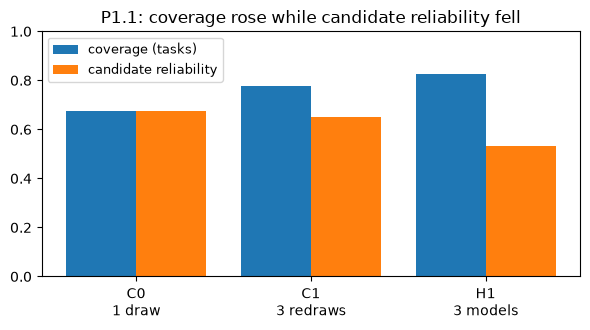

Do not simplify this to 'harder = better'. The harder corpus exposed a
real tradeoff and one clean rescue — alongside sampling variation, an
ambiguity, and a loss. Four tasks defeated every arm: the next ceiling.


In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3.4))
arms = ["C0", "C1", "H1"]
cov = [len(solved[a]) / 40 for a in arms]
rel = [passes[a] / total[a] for a in arms]
x = range(3)
ax.bar([i - 0.2 for i in x], cov, width=0.4, label="coverage (tasks)")
ax.bar([i + 0.2 for i in x], rel, width=0.4, label="candidate reliability")
ax.set_xticks(list(x), ["C0\n1 draw", "C1\n3 redraws", "H1\n3 models"])
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.set_title("P1.1: coverage rose while candidate reliability fell")
plt.tight_layout()
plt.show()
print("Do not simplify this to 'harder = better'. The harder corpus exposed a")
print("real tradeoff and one clean rescue — alongside sampling variation, an")
print("ambiguity, and a loss. Four tasks defeated every arm: the next ceiling.")

## Interpretation

1. **Potential coverage ≠ delivered reliability.** 33/40 tasks with at least
   one pass; only 64/120 candidates passing. Without a selector, the extra
   coverage is potential.
2. **A rescue ≠ a model-specific rescue.** Of three H1-only solves: one clean
   rescue, one sampling variation, one ambiguity — plus one task the
   portfolio lost.
3. **p = 0.625.** Not a proven advantage; the homogeneous default stays.
4. **"Harder" is scoped.** Harder *for this setup* (single-draw coverage
   11/12 → 27/40). Nothing here establishes hard problems in general, and
   hidden tests define correctness narrowly per task.

## Try it yourself

1. C0's single draw solved `v2-lsp-square` and `v2-unsound-cache`, which all
   six C1+H1 draws missed. Add that row to the discordant table: which way
   does sampling variation cut?
2. Recompute coverage with "task solved" = "≥2 of 3 draws pass". How does the
   H1–C1 gap change, and what does that say about the any-pass definition?
3. Four tasks defeated every arm. List them from the rows — that is the next
   benchmark's starting point, not a failure of this one.

*Evidence: `experiments/applied-ai/evidence/p-series/p11/p11-export.json`
(280 calls, 280 candidates, byte-pinned export + independent verifier). No
network, no API key, no `codeai` import.*